In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import datetime, os 
import matplotlib.pyplot as plt
%matplotlib inline

# AutoEncoders

## El AE más simple

El Autoencoder (AE) es una red neuronal artificial (ANN) cuyas capas de input y output tienen la misma cantidad de neuronas: los features. 

Poseen una `capa oculta` de menor dimensión que cumple el rol de *dimensión latente*. El entrenamiento es **no supervisado** (o más bien autosupervisado): la red busca aprender a reproducir el input. 

Reproducir el input implica que el algoritmo aprendió a codificar los datos en una **representación latente** (`encoder`) y decodificar esta representación latente y obtener los **features** (`decoder`). El objetivo es lograr esto con una pérdida mínima de información.

El AE más simple tiene una única capa oculta. Utilicemos este AE para codificar el dataset de MNIST a un vector de dimensión 32.

In [ ]:
#creamos una sesión limpia, nueva, borra memoria.
keras.backend.clear_session()

#Esta función no borra los pesos de los modelos, solo borra el grafo de computación y los valores de las variables internas de Keras. 
#Se debe utilizar antes de crear un nuevo modelo en la misma sesión para evitar conflictos en la memoria.

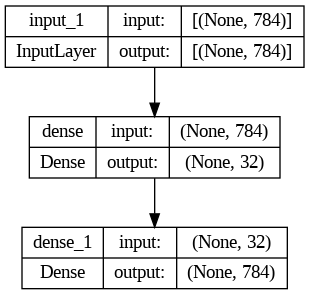

In [ ]:
# Definimos la dimensionalidad de nuestro espacio latente
encoding_dim = 32  # 32 floats -> factor de compresión 784/32 =  24.5

#Definimos el tamaño de la entrada
input_img = keras.layers.Input(shape=(784,)) 

#Capa oculta
encoded = keras.layers.Dense(encoding_dim, activation='relu')(input_img)

#output: usamos una función sigmoide para asegurarnos que los pixeles de salida estén entre 0 y 1
decoded = keras.layers.Dense(784, activation='sigmoid')(encoded)

#Creamos el modelo
autoencoder = keras.models.Model(input_img, decoded)

keras.utils.plot_model(autoencoder, show_shapes=True)

Este modelo tiene dos subredes.

El encoder:

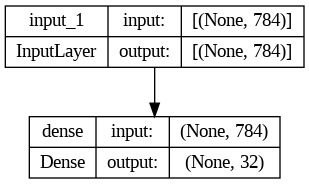

In [ ]:
encoder = keras.models.Model(input_img, encoded)
keras.utils.plot_model(encoder, show_shapes=True)

Y el decoder:

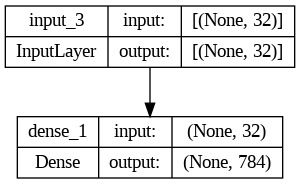

In [ ]:
# Necesitamos un input auxiliar de placehoder
encoded_input = keras.layers.Input(shape=(encoding_dim,))

#Obtenemos la última capa del autoencoder. En este caso, es el decoder
decoder_layer = autoencoder.layers[-1]

# Instanciamos el nuevo modelo aplicando el decoder al nuevo input
decoder = keras.models.Model(encoded_input, decoder_layer(encoded_input))

keras.utils.plot_model(decoder, show_shapes=True)

Antes de compilar, necesitamos definir la función de pérdida. Podríamos tratar esto como un problema de regresión pixel a pixel. Sin embargo, como tenemos 784 números entre 0 y 1, combiene pensar que tenemos 784 problemas binarios de clasificación y utilizar entropía cruzada.

In [ ]:
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 784)]             0         
                                                                 
 dense (Dense)               (None, 32)                25120     
                                                                 
 dense_1 (Dense)             (None, 784)               25872     
                                                                 
Total params: 50,992
Trainable params: 50,992
Non-trainable params: 0
_________________________________________________________________


In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

Veamos como funciona en MNIST:

In [ ]:
#Cargamos el dataset NMIST y dividimos el conjunto de datos en training y testing
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

#normalizamos a [0,1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
print(x_train.shape)
print(x_test.shape)

# Achatamos las imágenes: de 28x28 a un vector de dimensión 784
x_train = x_train.reshape(len(x_train), 784)
x_test = x_test.reshape(len(x_test), 784)
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000, 784)
(10000, 784)


Entrenamos:

In [ ]:
history = autoencoder.fit(x_train, x_train,
                          epochs=50,
                          batch_size=256,
                          shuffle=True,
                          validation_data=(x_test, x_test)
                          )

Epoch 1/50
235/235 [==============================] - 6s 5ms/step - loss: 0.2767 - val_loss: 0.1902
Epoch 2/50
235/235 [==============================] - 2s 7ms/step - loss: 0.1707 - val_loss: 0.1537
Epoch 3/50
235/235 [==============================] - 1s 6ms/step - loss: 0.1446 - val_loss: 0.1342
Epoch 4/50
235/235 [==============================] - 1s 4ms/step - loss: 0.1290 - val_loss: 0.1219
Epoch 5/50
235/235 [==============================] - 1s 4ms/step - loss: 0.1189 - val_loss: 0.1136
Epoch 6/50
235/235 [==============================] - 1s 4ms/step - loss: 0.1118 - val_loss: 0.1077
Epoch 7/50
235/235 [==============================] - 1s 4ms/step - loss: 0.1067 - val_loss: 0.1035
Epoch 8/50
235/235 [==============================] - 1s 4ms/step - loss: 0.1029 - val_loss: 0.1003
Epoch 9/50
235/235 [==============================] - 1s 4ms/step - loss: 0.1001 - val_loss: 0.0978
Epoch 10/50
235/235 [==============================] - 1s 4ms/step - loss: 0.0981 - val_loss: 0.0961

Habiendo entrenado nuestra red, podemos codificar imagenes de 28x28 y decodificarlas. Aunque entrenamos el autoencoder, por como definimos las cosas los pesos también están actualizados en el encoder y en el decoder.




In [ ]:
#encoding:
encoded_imgs = encoder.predict(x_test)

#decoding: (esto es analogo a autoencoder.predict(x_test))
decoded_imgs = decoder.predict(encoded_imgs)

313/313 [==============================] - 0s 1ms/step


Visualicemos algunas de estas imagenes

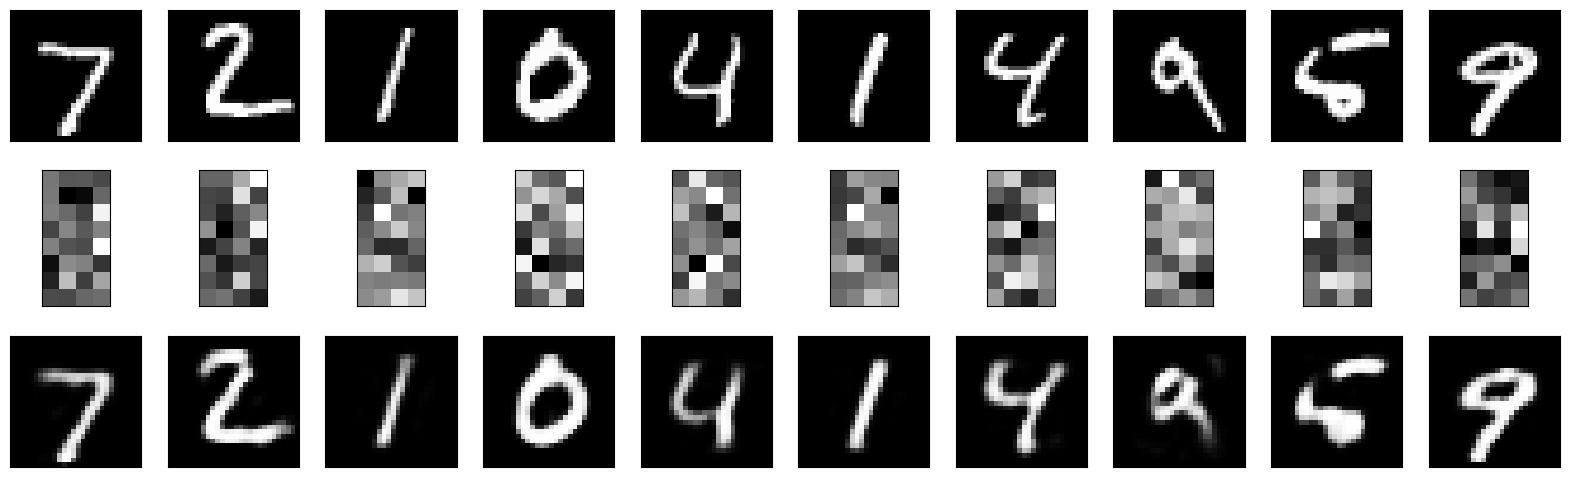

In [ ]:
n = 10  # cuantos digitos imprimimos
plt.figure(figsize=(20, 6))

for i in range(n):
    # original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # espacio latente
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(8, 4))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # reconstrucción
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Para lo simple que es... No es tan malo. Eso si, interpretar el espacio latente no es trivial (ni garantiza algo...)

## Deep AE

La idea de los AE simples se puede generalizar haciendo arquitecturas más profundas. Esto se suele llamar **Stacked AutoEncoders**. 

Debemos añadir más capas para permitir aprender codificaciones más complejas.

En general, la arquitectura de un stacked autoencoder es simétrica con respecto a la capa oculta central (la capa codificadora). 

![AutoEncoder from Wikipedia](https://upload.wikimedia.org/wikipedia/commons/2/28/Autoencoder_structure.png)

[1] Theis, L., Shi, W., Cunningham, A., & Huszár, F. (2017). Lossy image compression with compressive autoencoders. arXiv preprint arXiv:1703.00395.

`Atención`: puede pasar que el AE aprenda una codificación única para cada dato, esto implica que la representación de los datos no es útil y que probablemente generalice pésimo.

Nuevamente, volvamos al MNIST:

In [ ]:
keras.backend.clear_session()

In [ ]:
input_img = keras.layers.Input(shape=(784,))
encoded = keras.layers.Dense(128, activation='relu')(input_img)
encoded = keras.layers.Dense(64, activation='relu')(encoded)
encoded = keras.layers.Dense(32, activation='relu')(encoded)

decoded = keras.layers.Dense(64, activation='relu')(encoded)
decoded = keras.layers.Dense(128, activation='relu')(decoded)
decoded = keras.layers.Dense(784, activation='sigmoid')(decoded)

deep_autoencoder = keras.models.Model(input_img, decoded)

deep_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

deep_autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 784)]             0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 64)                2112      
                                                                 
 dense_4 (Dense)             (None, 128)               8320      
                                                                 
 dense_5 (Dense)             (None, 784)               101136

Entrenemos utilizando EarlyStopping:

In [ ]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
                                                  restore_best_weights=True)

history = deep_autoencoder.fit(x_train, x_train,
                               epochs=100,
                               batch_size=256,
                               shuffle=True,
                               validation_data=(x_test, x_test),
                               callbacks=[early_stopping_cb],
                               verbose=True)

Epoch 1/100
235/235 [==============================] - 2s 8ms/step - loss: 0.0904 - val_loss: 0.0896
Epoch 2/100
235/235 [==============================] - 1s 6ms/step - loss: 0.0901 - val_loss: 0.0891
Epoch 3/100
235/235 [==============================] - 1s 5ms/step - loss: 0.0897 - val_loss: 0.0888
Epoch 4/100
235/235 [==============================] - 1s 5ms/step - loss: 0.0895 - val_loss: 0.0884
Epoch 5/100
235/235 [==============================] - 1s 5ms/step - loss: 0.0891 - val_loss: 0.0884
Epoch 6/100
235/235 [==============================] - 1s 5ms/step - loss: 0.0888 - val_loss: 0.0879
Epoch 7/100
235/235 [==============================] - 2s 7ms/step - loss: 0.0885 - val_loss: 0.0879
Epoch 8/100
235/235 [==============================] - 1s 6ms/step - loss: 0.0883 - val_loss: 0.0878
Epoch 9/100
235/235 [==============================] - 1s 5ms/step - loss: 0.0880 - val_loss: 0.0873
Epoch 10/100
235/235 [==============================] - 1s 5ms/step - loss: 0.0878 - val_lo

Y veamos las imagenes resultantes

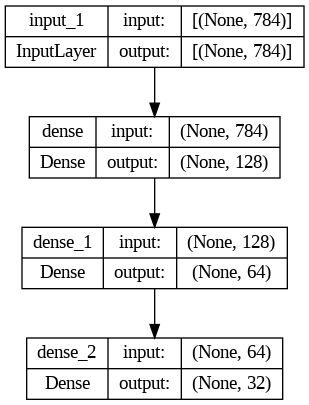

In [ ]:
encoder = keras.models.Model(input_img, encoded)
keras.utils.plot_model(encoder, show_shapes=True)

313/313 [==============================] - 1s 2ms/step


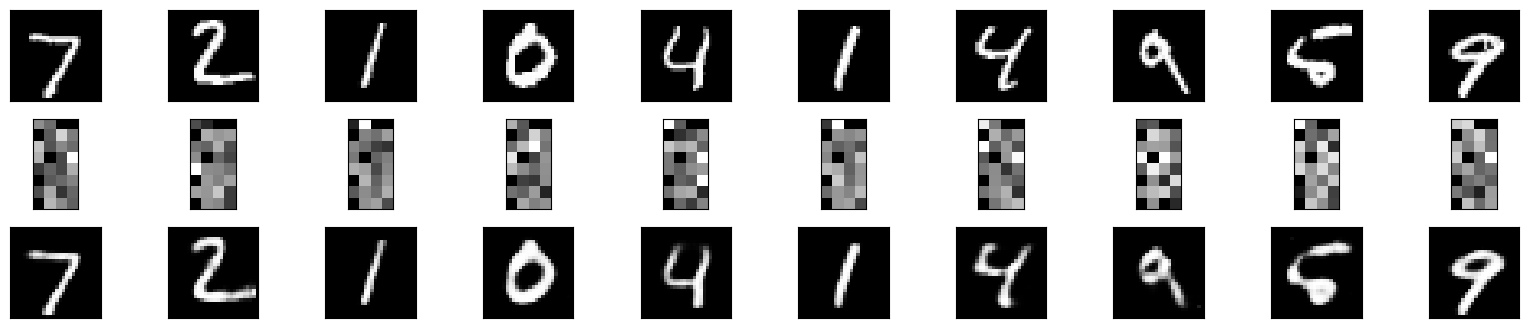

In [ ]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = deep_autoencoder.predict(x_test)

n = 10  
plt.figure(figsize=(20, 4))

for i in range(n):
    # espacio original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # espacio latente
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(8, 4))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # espacio reconstruido
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## Convolutional AutoEncoder:

Dado que estamos lidiando con imagenes, podemos incorporar capas convolucionales. La sutileza que aparece al incorporar capas convolucionales es que necesitamos regresar al tamaño original (lo que se llama _up-sampling_).

In [ ]:
keras.backend.clear_session()

In [ ]:
input_img = keras.layers.Input(shape=(28, 28, 1))

#Encoder: Conv -> MaxPool (x2)
x = keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = keras.layers.Conv2D(1, (3, 3), activation='relu', padding='same')(x)
encoded = keras.layers.MaxPooling2D((2, 2), padding='same')(x)

#La representación latente tiene shape (7, 7, 1) i.e. dimensión 49

#Decoder: Conv -> UpSampling (x3)
x = keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = keras.layers.UpSampling2D((2, 2))(x) #el UpSampling se ocupa de aumentar la dimensionalidad reptiendo las filas y las columnas por size[0] y size[1] respectivamente
x = keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = keras.layers.UpSampling2D((2, 2))(x)
decoded = keras.layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

conv_autoencoder = keras.models.Model(input_img, decoded)
conv_autoencoder.compile(loss='binary_crossentropy')

In [ ]:
conv_autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 1)         289       
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 1)          0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 32)          320   

Volvemos a importar el dataset para preservar las dimensiones

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

#normalizamos los pixeles [0,1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [ ]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
                                                  restore_best_weights=True)

hist = conv_autoencoder.fit(x_train, x_train,
                            epochs=100,
                            batch_size=128,
                            shuffle=True,
                            validation_data=(x_test, x_test),
                            callbacks=[early_stopping_cb])

Epoch 1/100
469/469 [==============================] - 11s 11ms/step - loss: 0.1807 - val_loss: 0.1362
Epoch 2/100
469/469 [==============================] - 3s 6ms/step - loss: 0.1326 - val_loss: 0.1262
Epoch 3/100
469/469 [==============================] - 3s 6ms/step - loss: 0.1241 - val_loss: 0.1216
Epoch 4/100
469/469 [==============================] - 3s 6ms/step - loss: 0.1185 - val_loss: 0.1157
Epoch 5/100
469/469 [==============================] - 3s 7ms/step - loss: 0.1145 - val_loss: 0.1112
Epoch 6/100
469/469 [==============================] - 3s 6ms/step - loss: 0.1115 - val_loss: 0.1114
Epoch 7/100
469/469 [==============================] - 3s 6ms/step - loss: 0.1091 - val_loss: 0.1073
Epoch 8/100
469/469 [==============================] - 4s 8ms/step - loss: 0.1072 - val_loss: 0.1053
Epoch 9/100
469/469 [==============================] - 3s 7ms/step - loss: 0.1056 - val_loss: 0.1059
Epoch 10/100
469/469 [==============================] - 3s 6ms/step - loss: 0.1042 - val_

313/313 [==============================] - 1s 2ms/step


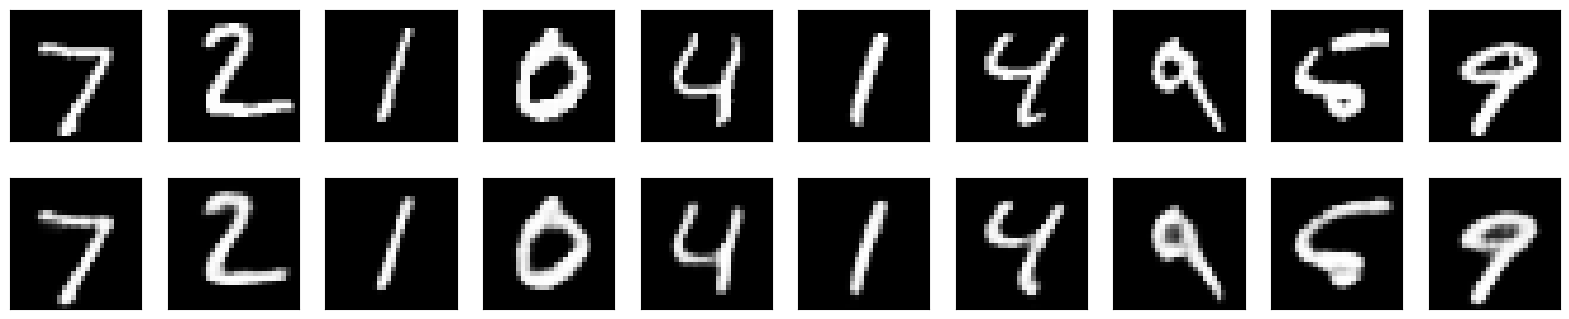

In [ ]:
decoded_imgs = conv_autoencoder.predict(x_test)

n = 10  # how many digits we will display
plt.figure(figsize=(20, 4))

for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].squeeze())
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
plt.show()

### Noise reduction

Una posible aplicación de los AEs es en la tarea de denosing o "limpieza" de los datos. Cualquier ruido que no siga los patrones del conjunto de entrenamiento será "limpiado" al pasar a través del AE. Veamoslo con nuestro AE convolucional agregando un poco de ruido.

In [ ]:
#Agregamos ruido gaussiano a nuestras imagenes
noise_factor = 0.2

x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape) 

#Nos aseguramos de que los pixeles estén en el rango [0,1] utilizando saturación.
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

Estas son las imagenes ruidosas:

Original


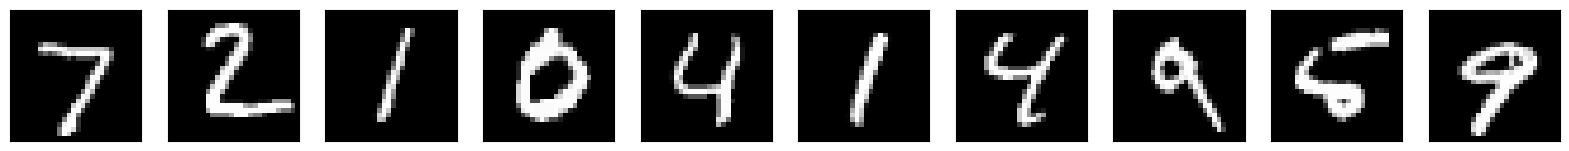

Ruidosa


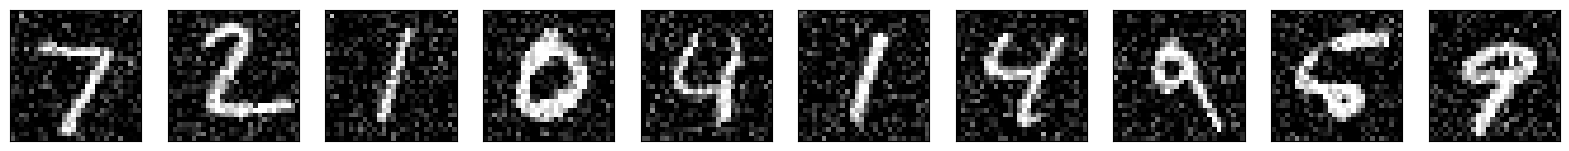

In [ ]:
n = 10
plt.figure(figsize=(20, 2))
print("Original")

for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

print("Ruidosa")
plt.figure(figsize=(20, 2))

for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test_noisy[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Veamos como limpia las imágenes contaminadas con ruido el AE:

In [ ]:
x_test_cleaned = conv_autoencoder.predict(x_test_noisy)

313/313 [==============================] - 1s 3ms/step


Original


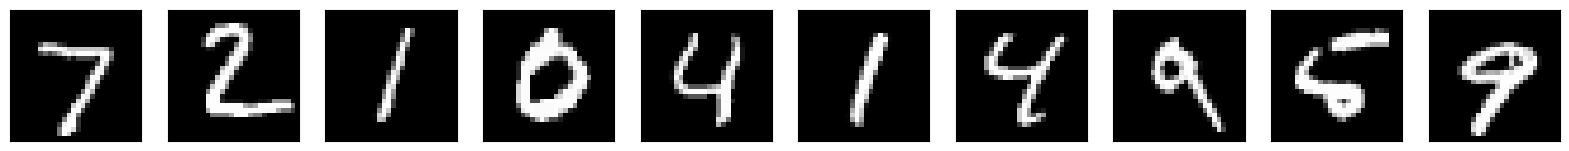

Ruidosa


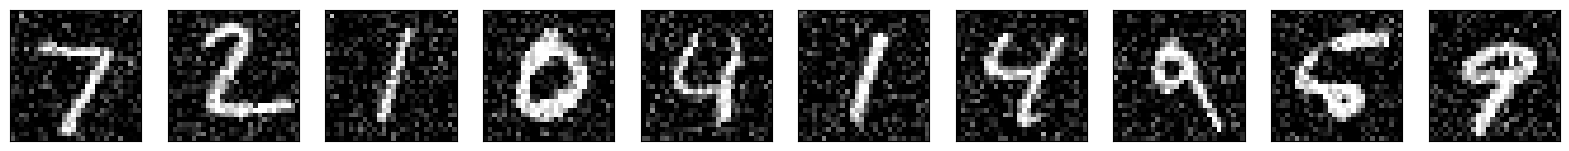

Limpia


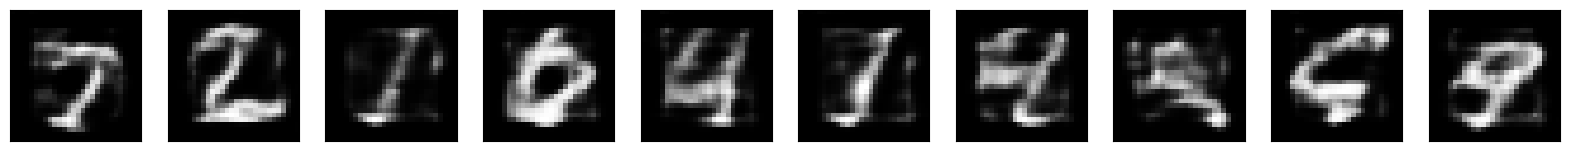

In [ ]:
n = 10
print("Original")
plt.figure(figsize=(20, 2))

for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

print("Ruidosa")
plt.figure(figsize=(20, 2))

for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test_noisy[i].squeeze())
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

plt.figure(figsize=(20, 2))
print("Limpia")

for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test_cleaned[i].squeeze())
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Podemos aplicar el AE muchas veces para tratar de sacar más ruido. Sin embargo, esto puede magnificar cualquier distorsión que tenga el AE.

313/313 [==============================] - 1s 3ms/step
Limpia


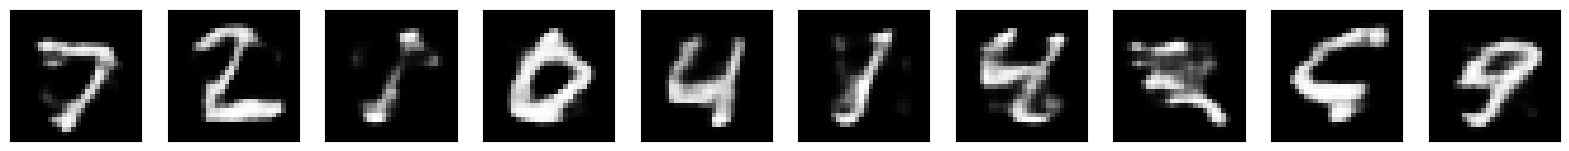

In [ ]:
#Iteremos
x_test_cleaned = conv_autoencoder.predict(x_test_cleaned)

#Visualicemos
plt.figure(figsize=(20, 2))
print("Limpia")

for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test_cleaned[i].squeeze())
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## Denoising AutoEncoders:

Sin embargo, si lo que nos interesa es quitar el ruido conviene entrenar un AE para ese rol. Esta idea consiste en agregar ruido a los datos de entrenamiento y entrenar la AE para recuperar la imagen "limpia". 

El ruido puede agregarse como ruido normal o puede implementarse añadiendo una capa de Dropout que apague algunos pixeles (que pueden jugar el rol de, por ejemplo, pixeles muertos en una CCD).

In [ ]:
keras.backend.clear_session()

dropout_encoder = keras.models.Sequential([
    keras.layers.Dropout(0.2, input_shape=(28,28,1)),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2), padding='same'),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2), padding='same')
])

dropout_decoder = keras.models.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.UpSampling2D((2, 2)),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.UpSampling2D((2, 2)),
    keras.layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
])

dropout_autoencoder = keras.models.Sequential([dropout_encoder, dropout_decoder])

dropout_autoencoder.compile(loss='binary_crossentropy')

In [ ]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
                                                  restore_best_weights=True)

hist = dropout_autoencoder.fit(x_train, x_train,
                            epochs=100,
                            batch_size=128,
                            shuffle=True,
                            validation_data=(x_test, x_test),
                            callbacks=[early_stopping_cb])

Epoch 1/100
469/469 [==============================] - 5s 8ms/step - loss: 0.1224 - val_loss: 0.0902
Epoch 2/100
469/469 [==============================] - 3s 7ms/step - loss: 0.0868 - val_loss: 0.0837
Epoch 3/100
469/469 [==============================] - 3s 6ms/step - loss: 0.0816 - val_loss: 0.0802
Epoch 4/100
469/469 [==============================] - 3s 6ms/step - loss: 0.0789 - val_loss: 0.0765
Epoch 5/100
469/469 [==============================] - 3s 7ms/step - loss: 0.0774 - val_loss: 0.0770
Epoch 6/100
469/469 [==============================] - 3s 7ms/step - loss: 0.0763 - val_loss: 0.0757
Epoch 7/100
469/469 [==============================] - 3s 6ms/step - loss: 0.0755 - val_loss: 0.0740
Epoch 8/100
469/469 [==============================] - 3s 6ms/step - loss: 0.0748 - val_loss: 0.0760
Epoch 9/100
469/469 [==============================] - 3s 7ms/step - loss: 0.0743 - val_loss: 0.0747
Epoch 10/100
469/469 [==============================] - 3s 7ms/step - loss: 0.0739 - val_lo

Veamos como funciona y comparemos con el AE anterior

In [ ]:
x_test_cleaned_do = dropout_autoencoder.predict(x_test_noisy)

313/313 [==============================] - 1s 2ms/step


Original


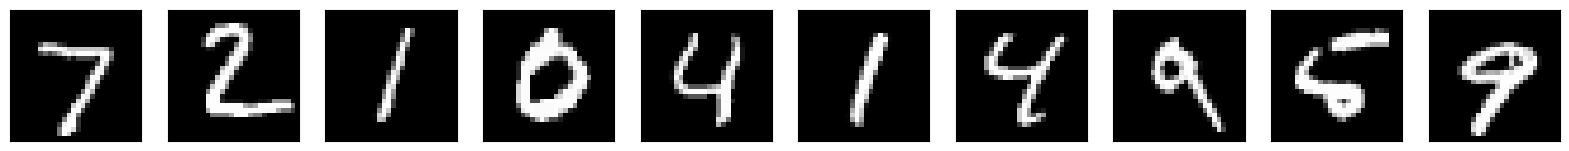

Ruidosa


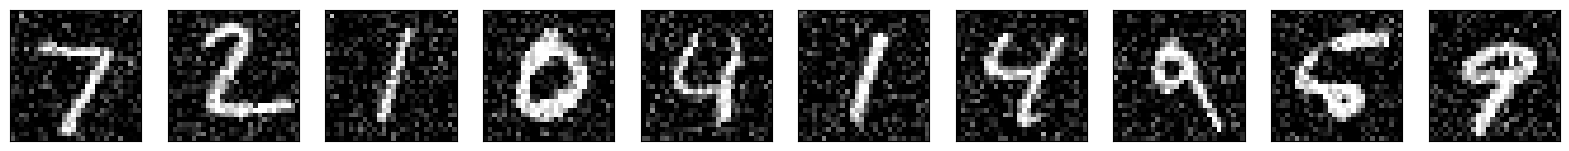

Limpia (sin DropOut)


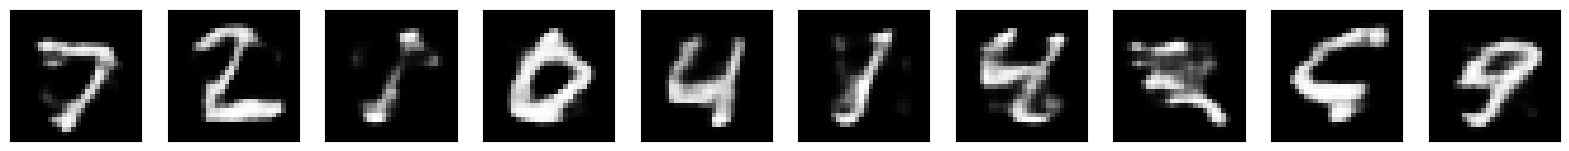

Limpia (con DropOut)


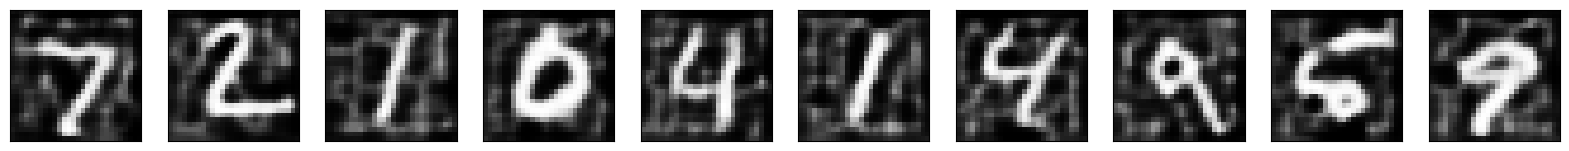

In [ ]:
n = 10

print("Original")
plt.figure(figsize=(20, 2))

for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

print("Ruidosa")
plt.figure(figsize=(20, 2))

for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

plt.figure(figsize=(20, 2))
print("Limpia (sin DropOut)")

for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test_cleaned[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

plt.figure(figsize=(20, 2))
print("Limpia (con DropOut)")

for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test_cleaned_do[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()